In [ ]:
!wget https://antidote.cloud/f/ae5312aa983845c7abf1/?dl=1 -O llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl
!CMAKE_ARGS="-DGGML_CUDA=on" pip install /content/llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl
!pip install -q kagglehub pandas numpy matplotlib scipy sentence-transformers pytrends huggingface_hub hf_transfer

--2026-03-30 21:08:38--  https://antidote.cloud/f/ae5312aa983845c7abf1/?dl=1
Resolving antidote.cloud (antidote.cloud)... 193.30.122.219
Connecting to antidote.cloud (antidote.cloud)|193.30.122.219|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://antidote.cloud/seafhttp/files/1f1f030f-d1b6-468d-9e02-a51a87f7bb2a/llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl [following]
--2026-03-30 21:08:39--  https://antidote.cloud/seafhttp/files/1f1f030f-d1b6-468d-9e02-a51a87f7bb2a/llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl
Reusing existing connection to antidote.cloud:443.
HTTP request sent, awaiting response... 200 OK
Length: 52058581 (50M) [application/octet-stream]
Saving to: ‘llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl’

llama_cpp_python-0. 100%[===================>]  49.65M  11.7MB/s    in 4.2s    

2026-03-30 21:08:44 (11.7 MB/s) - ‘llama_cpp_python-0.3.16-cp312-cp312-linux_x86_64.whl’ saved [52058581/52058581]

Processing ./llama

In [ ]:
# Imports and seed
import pandas as pd
import numpy as np
import torch
import random
import os
import time
import json
import gc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f'Seed:    {SEED}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU:     {props.name}')
    print(f'VRAM:    {props.total_memory / 1e9:.1f} GB')

Seed:    42
PyTorch: 2.10.0+cu128
CUDA:    True
GPU:     Tesla T4
VRAM:    15.6 GB


In [ ]:
# download mistral nemo
%env HF_HUB_ENABLE_HF_TRANSFER=1
!hf download bartowski/Mistral-Nemo-Instruct-2407-GGUF Mistral-Nemo-Instruct-2407-Q5_K_M.gguf --local-dir .

env: HF_HUB_ENABLE_HF_TRANSFER=1
A new version of huggingface_hub (1.8.0) is available! You are using version 1.7.1.
To update, run: pip install -U huggingface_hub

Mistral-Nemo-Instruct-2407-Q5_K_M.gguf: 100% 8.73G/8.73G [00:24<00:00, 353MB/s]
Mistral-Nemo-Instruct-2407-Q5_K_M.gguf


In [ ]:
# Load Reddit data
import kagglehub

path = kagglehub.dataset_download('aravindrajpalepu/teslaissues-reddit')
reddit_raw = pd.read_csv(os.path.join(path, 'tesla_issues1.csv'))

print(f'Reddit posts loaded: {len(reddit_raw):,}')
print(f'Columns: {reddit_raw.columns.tolist()}')

100%|██████████| 292M/292M [00:21<00:00, 14.5MB/s]

Extracting files...


Reddit posts loaded: 163,857
Columns: ['keyword_combinations', 'Post Title', 'Post Date', 'Post Text']


In [ ]:
# reddit data preprocessing
df = reddit_raw.copy()
df['Post Date']  = pd.to_datetime(df['Post Date'], errors='coerce')
df['Post Title'] = df['Post Title'].fillna('').astype(str)
df['Post Text']  = df['Post Text'].fillna('').astype(str)

df = df[
    (df['Post Title'].str.strip() != '') |
    (df['Post Text'].str.strip()  != '')
].dropna(subset=['Post Date']).copy()

df['full_text'] = (
    df['Post Title'].str.strip() + '. ' + df['Post Text'].str.strip()
).str.strip()

df = df.drop_duplicates(subset=['full_text']).copy()

df['week_start'] = df['Post Date'].dt.to_period('W-SUN').dt.start_time

STUDY_START = df['Post Date'].min()
STUDY_END   = df['Post Date'].max()

raw_count   = len(reddit_raw)
clean_count = len(df)
print(f'Raw posts:     {raw_count:,}')
print(f'Clean posts:   {clean_count:,}')
print(f'Noise removed: {(raw_count - clean_count) / raw_count * 100:.1f}%')
print(f'Study window:  {STUDY_START.date()} → {STUDY_END.date()}')

Raw posts:     163,857
Clean posts:   29,245
Noise removed: 82.2%
Study window:  2023-09-22 → 2024-09-21


In [ ]:
# Load and Filter Recalls data
NHTSA_URL = 'https://data.transportation.gov/api/views/6axg-epim/rows.csv?accessType=DOWNLOAD'
recalls_raw = pd.read_csv(NHTSA_URL)

tesla_recalls = recalls_raw[
    recalls_raw['Manufacturer'].str.contains('Tesla', case=False, na=False)
].copy()

tesla_recalls['Report Received Date'] = pd.to_datetime(
    tesla_recalls['Report Received Date'], errors='coerce'
)

# Filter to Reddit study window
tesla_recalls = tesla_recalls[
    (tesla_recalls['Report Received Date'] >= STUDY_START) &
    (tesla_recalls['Report Received Date'] <= STUDY_END)
].copy()

# Assign week_start using the same period convention as Reddit
tesla_recalls['week_start'] = (
    tesla_recalls['Report Received Date']
    .dt.to_period('W-SUN').dt.start_time
)

weekly_recalls = (
    tesla_recalls.groupby('week_start').size()
    .reset_index(name='recall_count')
)
weekly_recalls['week_start']    = pd.to_datetime(weekly_recalls['week_start'])
weekly_recalls['recall_binary'] = 1

print(f'Tesla recalls in study window: {len(tesla_recalls):,}')
print(f'Recall weeks: {len(weekly_recalls)}')
print(f'Date range: {tesla_recalls["Report Received Date"].min().date()} → {tesla_recalls["Report Received Date"].max().date()}')

Tesla recalls in study window: 14
Recall weeks: 12
Date range: 2023-10-11 → 2024-08-15


In [ ]:
#Load google Trends data
from pytrends.request import TrendReq

start_str = STUDY_START.strftime('%Y-%m-%d')
end_str   = STUDY_END.strftime('%Y-%m-%d')
print(f'Trends window: {start_str} → {end_str}')


pytrends = TrendReq(hl='en-US', tz=360)
pytrends.build_payload(
    kw_list=['Tesla recalls'],
    timeframe=f'{start_str} {end_str}',
    geo='US'
)
time.sleep(2)
trends_raw = (
    pytrends.interest_over_time()
    .reset_index()[['date', 'Tesla recalls']]
    .rename(columns={'date': 'week_start', 'Tesla recalls': 'GTI'})
)
trends_raw['week_start'] = pd.to_datetime(trends_raw['week_start'])
print(f'Google Trends rows: {len(trends_raw)}')
print(trends_raw.head(15))

Trends window: 2023-09-22 → 2024-09-21
Google Trends rows: 53
   week_start  GTI
0  2023-09-17    0
1  2023-09-24    0
2  2023-10-01    0
3  2023-10-08    0
4  2023-10-15    0
5  2023-10-22    0
6  2023-10-29    3
7  2023-11-05    0
8  2023-11-12    0
9  2023-11-19    0
10 2023-11-26    0
11 2023-12-03    3
12 2023-12-10  100
13 2023-12-17   27
14 2023-12-24   20


In [ ]:
#embed cleaned posts
from sentence_transformers import SentenceTransformer, util

embedder = SentenceTransformer('all-MiniLM-L6-v2')
texts    = df['full_text'].fillna('').astype(str).tolist()

print(f'Embedding {len(texts):,} posts with all-MiniLM-L6-v2...')
embeddings_np = embedder.encode(
    texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

# Free embedder for GPU
del embedder
gc.collect()
torch.cuda.empty_cache()

print(f'Embeddings shape: {embeddings_np.shape}')
print(f'GPU memory free:  {torch.cuda.memory_allocated()/1e9:.2f} GB allocated')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 29,245 posts with all-MiniLM-L6-v2...


Batches:   0%|          | 0/115 [00:00<?, ?it/s]

Embeddings shape: (29245, 384)
GPU memory free:  0.01 GB allocated


In [ ]:
# community detection
# High-threshold clustering intentionally excludes ambiguous posts
t0 = time.time()

embedding_tensor_cpu = torch.tensor(embeddings_np)

clusters = util.community_detection(
    embedding_tensor_cpu,
    min_community_size=15,
    threshold=0.75
)

print(f'Done in {time.time() - t0:.1f}s')
print(f'Communities found: {len(clusters)}')
for i, c in enumerate(clusters[:10]):
    print(f'  Cluster {i:2d}: {len(c):5d} posts')

del embedding_tensor_cpu
gc.collect()

Done in 3.9s
Communities found: 34
  Cluster  0:   216 posts
  Cluster  1:    98 posts
  Cluster  2:    82 posts
  Cluster  3:    60 posts
  Cluster  4:    53 posts
  Cluster  5:    45 posts
  Cluster  6:    45 posts
  Cluster  7:    43 posts
  Cluster  8:    39 posts
  Cluster  9:    30 posts


0

In [ ]:
#assign cluster ID
df['cluster_id'] = -1

for cluster_idx, cluster in enumerate(clusters):
    for row_idx in cluster:
        df.loc[row_idx, 'cluster_id'] = cluster_idx

clustered_df    = df[df['cluster_id'] != -1].copy()
cluster_sizes   = clustered_df['cluster_id'].value_counts().sort_values(ascending=False)
top_cluster_ids = cluster_sizes.head(10).index.tolist()

coverage_pct = len(clustered_df) / len(df) * 100
print(f'Posts in a cluster: {len(clustered_df):,} / {len(df):,} ({coverage_pct:.1f}%)')
print(f'Unique clusters:    {clustered_df["cluster_id"].nunique()}')
print('\nTop 10 cluster sizes:')
print(cluster_sizes.head(10).to_string())

Posts in a cluster: 1,182 / 29,987 (3.9%)
Unique clusters:    34

Top 10 cluster sizes:
cluster_id
0.0    216
1.0     98
2.0     82
3.0     60
4.0     53
6.0     45
5.0     45
7.0     43
8.0     39
9.0     30


In [ ]:
#Load Mistral Nemo
from llama_cpp import Llama, LlamaGrammar

llm = Llama(
    model_path='/content/Mistral-Nemo-Instruct-2407-Q5_K_M.gguf',
    n_ctx=2048,
    n_gpu_layers=-1,
    n_threads=8,
    n_batch=512,
    verbose=False,
    seed=SEED
)

llama_context: n_ctx_per_seq (2048) < n_ctx_train (1024000) -- the full capacity of the model will not be utilized


In [ ]:
LABEL_SCHEMA = {
    'type': 'object',
    'properties': {
        'label':       {'type': 'string'},
        'description': {'type': 'string'}
    },
    'required': ['label', 'description']
}
label_grammar = LlamaGrammar.from_json_schema(json.dumps(LABEL_SCHEMA))

In [ ]:
#cluster labelling with Mistral Nemo
def get_cluster_samples(df_in, cluster_id, n=3, max_chars=250):
    """Return n posts from a cluster, each truncated to max_chars."""
    texts = (
        df_in[df_in['cluster_id'] == cluster_id]['full_text']
        .dropna().astype(str).str.strip()
    )
    if len(texts) == 0:
        return []
    return [
        t[:max_chars]
        for t in texts.sample(min(n, len(texts)), random_state=SEED).tolist()
    ]


def label_cluster(cluster_id, df_in):
    """Label one cluster using Mistral Nemo with GBNF grammar-constrained JSON."""
    samples = get_cluster_samples(df_in, cluster_id)
    if not samples:
        return {'label': f'cluster_{cluster_id}', 'description': 'No samples.'}

    joined = '\n'.join([f'- {s}' for s in samples])
    system_prompt = (
        'You are an automotive safety intelligence analyst. '
        'Classify the following Reddit posts into a short safety topic label. '
        'Focus on vehicle safety, defects, recalls, and malfunctions.'
    )
    prompt = (
        f'[INST] {system_prompt}\n\n'
        'These posts belong to the same semantic cluster:\n\n'
        f'{joined}\n\n'
        'Identify the precise vehicle safety issue, focusing on the root cause or primary safety symptom. '
        'Return JSON with a short, specific label (max 5 words) for the *safety issue* and a 1-sentence description detailing the safety concern. [/INST]'
    )

    try:
        output = llm(
            prompt,
            max_tokens=80,
            temperature=0,
            grammar=label_grammar
        )
        result = json.loads(output['choices'][0]['text'].strip())
        gc.collect()
        return result
    except Exception as e:
        gc.collect()
        return {'label': f'cluster_{cluster_id}', 'description': f'Failed: {e}'}


# Label top 10 clusters
cluster_labels = {}
for cid in top_cluster_ids:
    print(f'Labeling cluster {cid}...')
    cluster_labels[cid] = label_cluster(cid, clustered_df)
    print(f'  → {cluster_labels[cid]["label"]}')

print('\n Labelling complete')


Labeling cluster 0.0...
  → Windshield Fluid Compatibility
Labeling cluster 1.0...
  → Key Fob Safety
Labeling cluster 2.0...
  → Water Damage Vulnerability
Labeling cluster 3.0...
  → Tesla App Malfunction
Labeling cluster 4.0...
  → Key Fob Programming Issue
Labeling cluster 6.0...
  → Autopilot Safety Concerns
Labeling cluster 5.0...
  → Window Malfunction
Labeling cluster 7.0...
  → Key/Phone Access Security
Labeling cluster 8.0...
  → Lane Detection Malfunction
Labeling cluster 9.0...
  → Battery Drain Issue

 Labelling complete


In [ ]:
#merge labels to build weekly pivot
cluster_labels_df = pd.DataFrame([
    {'cluster_id': cid, 'cluster_name': info['label']}
    for cid, info in cluster_labels.items()
])

clustered_df = clustered_df.merge(cluster_labels_df, on='cluster_id', how='left')
clustered_df['cluster_name'] = clustered_df['cluster_name'].fillna('other')
clustered_df['week_start']   = pd.to_datetime(clustered_df['week_start'])

# Weekly post count per named cluster — the multi-dimensional SCI
topic_weekly = (
    clustered_df
    .groupby(['week_start', 'cluster_name'])
    .size()
    .reset_index(name='post_count')
    .pivot(index='week_start', columns='cluster_name', values='post_count')
    .fillna(0)
    .sort_index()
)
topic_weekly.index          = pd.to_datetime(topic_weekly.index)
topic_weekly.columns.name   = None

print(f'Multi-dimensional SCI: {topic_weekly.shape[1]} clusters × {topic_weekly.shape[0]} weeks')
print(topic_weekly.head(3))

Multi-dimensional SCI: 11 clusters × 52 weeks
            Autopilot Safety Concerns  Battery Drain Issue  \
week_start                                                   
2023-09-18                        0.0                  0.0   
2023-09-25                        0.0                  0.0   
2023-10-02                        0.0                  0.0   

            Key Fob Programming Issue  Key Fob Safety  \
week_start                                              
2023-09-18                        0.0             0.0   
2023-09-25                        0.0             1.0   
2023-10-02                        0.0             0.0   

            Key/Phone Access Security  Lane Detection Malfunction  \
week_start                                                          
2023-09-18                        0.0                         0.0   
2023-09-25                        0.0                         0.0   
2023-10-02                        0.0                         0.0   

           

In [ ]:
# baseline — aggregate SCI

weekly_total  = df.groupby('week_start').size().rename('total_posts')
weekly_clust  = clustered_df.groupby('week_start').size().rename('clustered_posts')

sci_weekly = pd.concat([weekly_total, weekly_clust], axis=1).fillna(0)
sci_weekly['SCI'] = sci_weekly['clustered_posts'] / sci_weekly['total_posts']
sci_weekly = sci_weekly.reset_index()
sci_weekly['week_start'] = pd.to_datetime(sci_weekly['week_start']).dt.normalize()

trends_aligned = trends_raw.copy()
trends_aligned['week_start'] = pd.to_datetime(trends_aligned['week_start']).dt.normalize()

if not (trends_aligned['GTI'] == 0).all():
    first_nonzero = trends_aligned['GTI'].ne(0).idxmax()
    trends_aligned = trends_aligned.loc[first_nonzero:].copy()
    trends_aligned['GTI'] = trends_aligned['GTI'].replace(0, np.nan).ffill().bfill()

merged = (
    sci_weekly
    .merge(weekly_recalls[['week_start', 'recall_binary', 'recall_count']],
           on='week_start', how='left')
    .merge(trends_aligned, on='week_start', how='left')
)

merged['recall_binary'] = merged['recall_binary'].fillna(0).astype(int)
merged['recall_count']  = merged['recall_count'].fillna(0).astype(int)
merged['GTI']           = merged['GTI'].fillna(0)

r_nhtsa, p_nhtsa = pearsonr(merged['SCI'], merged['recall_binary'])

if merged['GTI'].std() > 0:
    r_gti, p_gti = pearsonr(merged['SCI'], merged['GTI'])
else:
    r_gti, p_gti = np.nan, np.nan

print(f"  SCI vs NHTSA recalls:  r={r_nhtsa:.3f}, p={p_nhtsa:.4f}")
gti_str = f"r={r_gti:.3f}, p={p_gti:.4f}" if not (isinstance(r_gti, float) and __import__("math").isnan(r_gti)) else "NaN (GTI constant after merge)"
print(f"  SCI vs Google Trends:  {gti_str}")


  SCI vs NHTSA recalls:  r=0.090, p=0.5225
  SCI vs Google Trends:  NaN (GTI constant after merge)


In [ ]:
# per cluster pearson r
aligned = (
    merged[["week_start", "recall_binary", "GTI"]]
    .merge(topic_weekly.reset_index(), on="week_start", how="inner")
)

print("Per-cluster Pearson r")
import math
gti_str = f"{r_gti:.3f}" if not (isinstance(r_gti, float) and math.isnan(r_gti)) else "NaN"
print(f"baseline → r_NHTSA={r_nhtsa:.3f} | r_GTI={gti_str}")
print("=" * 65)

corr_rows = []
for cluster in topic_weekly.columns:
    r_n, p_n = pearsonr(aligned[cluster], aligned["recall_binary"])
    r_g, p_g = pearsonr(aligned[cluster], aligned["GTI"])
    corr_rows.append({
        "cluster":          cluster,
        "r_vs_NHTSA":       round(r_n, 3),
        "p_NHTSA":          round(p_n, 4),
        "r_vs_GTI":         round(r_g, 3),
        "p_GTI":            round(p_g, 4),
        "beats_baseline":   "✓" if r_n > r_nhtsa else ""
    })

corr_df = pd.DataFrame(corr_rows).sort_values("r_vs_NHTSA", ascending=False)
print(corr_df.to_string(index=False))

Per-cluster Pearson r
baseline → r_NHTSA=0.090 | r_GTI=NaN
                       cluster  r_vs_NHTSA  p_NHTSA  r_vs_GTI  p_GTI beats_baseline
            Window Malfunction       0.192   0.1726       NaN    NaN              ✓
    Water Damage Vulnerability       0.183   0.1932       NaN    NaN              ✓
         Tesla App Malfunction       0.096   0.4962       NaN    NaN              ✓
    Lane Detection Malfunction       0.080   0.5710       NaN    NaN               
     Key/Phone Access Security       0.046   0.7446       NaN    NaN               
           Battery Drain Issue      -0.008   0.9538       NaN    NaN               
     Key Fob Programming Issue      -0.011   0.9379       NaN    NaN               
                Key Fob Safety      -0.020   0.8863       NaN    NaN               
                         other      -0.053   0.7096       NaN    NaN               
     Autopilot Safety Concerns      -0.059   0.6794       NaN    NaN               
Windshield Fluid 

/tmp/ipykernel_30396/1856401029.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_g, p_g = pearsonr(aligned[cluster], aligned["GTI"])


In [ ]:
#per cluster alert threshholds
print('Per-cluster alert thresholds (mean + 1 standard deviation)')
print('=' * 60)

alert_rows = []
for col in topic_weekly.columns:
    s         = topic_weekly[col]
    threshold = s.mean() + s.std()
    spikes    = s[s > threshold]
    alert_rows.append({
        'cluster':     col,
        'mean':        round(s.mean(),  1),
        'std':         round(s.std(),   1),
        'threshold':   round(threshold, 1),
        'alert_weeks': len(spikes)
    })

alerts_df = pd.DataFrame(alert_rows).sort_values('alert_weeks', ascending=False)
print(alerts_df.to_string(index=False))

Per-cluster alert thresholds (mean + 1 standard deviation)
                       cluster  mean  std  threshold  alert_weeks
     Autopilot Safety Concerns   0.3  0.5        0.9           14
    Lane Detection Malfunction   0.3  0.6        0.9           13
     Key/Phone Access Security   0.3  0.5        0.8           13
            Window Malfunction   0.2  0.5        0.7           12
           Battery Drain Issue   0.2  0.4        0.6            8
Windshield Fluid Compatibility   1.3  1.4        2.7            8
     Key Fob Programming Issue   0.5  1.0        1.5            6
    Water Damage Vulnerability   0.5  0.8        1.3            6
                Key Fob Safety   0.4  0.7        1.1            4
                         other   4.0  2.4        6.4            4
         Tesla App Malfunction   0.4  0.7        1.0            3


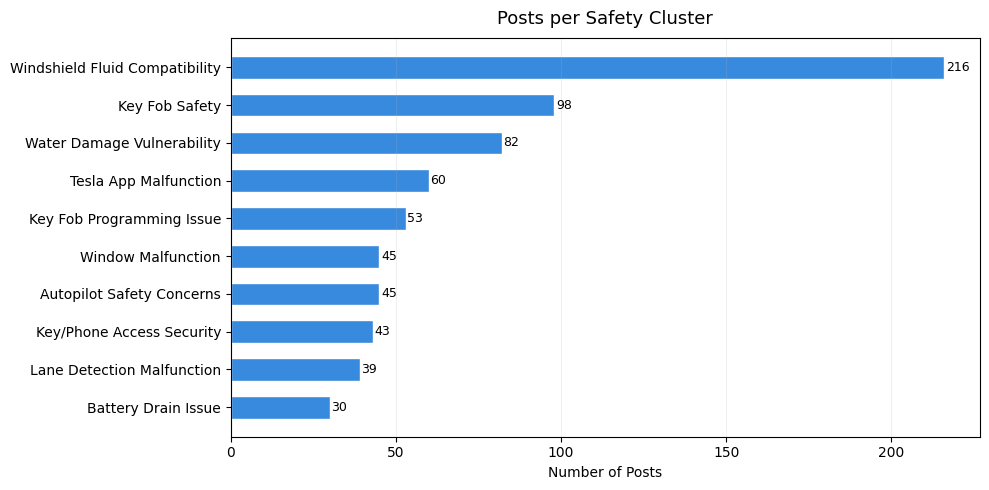

In [ ]:
# Plot: cluster size distribution
size_df = (
    clustered_df[clustered_df['cluster_name'] != 'other']
    .groupby('cluster_name').size()
    .sort_values(ascending=True)
    .reset_index(name='post_count')
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(size_df['cluster_name'], size_df['post_count'],
        color='#378ADD', edgecolor='white', height=0.6)
ax.set_xlabel('Number of Posts')
ax.set_title('Posts per Safety Cluster', fontsize=13, pad=10)
ax.grid(axis='x', alpha=0.2)
for i, v in enumerate(size_df['post_count']):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()


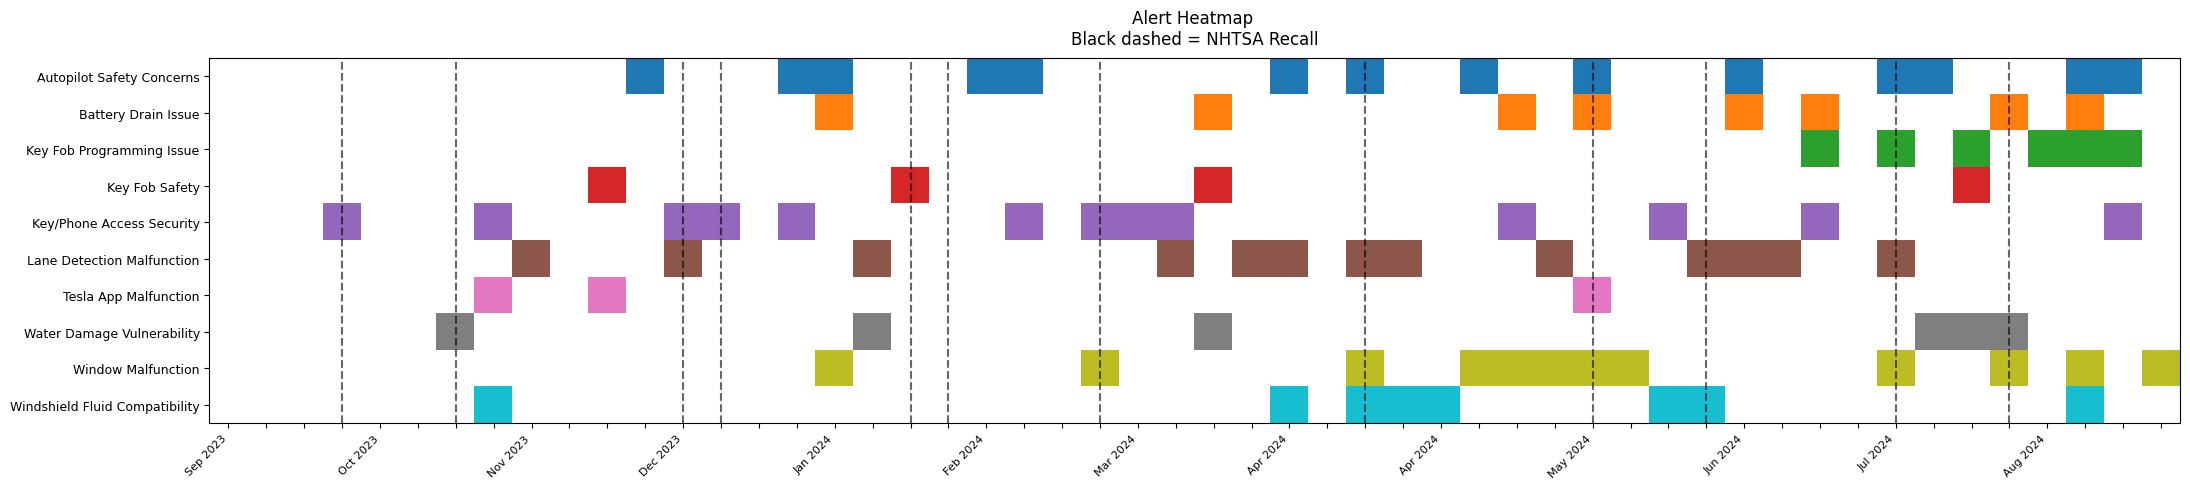

In [ ]:
# Plot: alert heatmap — which clusters spike in which weeks
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

plot_cols  = [c for c in topic_weekly.columns if c.lower() != 'other']
topic_plot = topic_weekly[plot_cols].copy()

# Build binary alert matrix (1 = above threshold)
thresholds = {col: topic_plot[col].mean() + topic_plot[col].std() for col in plot_cols}
alert_matrix = pd.DataFrame({
    col: (topic_plot[col] > thresholds[col]).astype(int)
    for col in plot_cols
}).T # Transpose to have clusters as rows for imshow

# Prepare unique colors for each cluster
colors_list = [cm.tab10(i) for i in range(len(plot_cols))]

# Create an empty RGB array for the heatmap, initialized to white
heatmap_rgb = np.ones((len(plot_cols), len(topic_plot.index), 3))

# Populate the RGB array based on alert status and cluster colors
for i, cluster_name in enumerate(plot_cols):
    for j, is_alert in enumerate(alert_matrix.loc[cluster_name]):
        if is_alert == 1:
            # Assign the cluster's unique color (RGB part)
            heatmap_rgb[i, j, :] = colors_list[i][:3]

fig, ax = plt.subplots(figsize=(22, 5))
im = ax.imshow(heatmap_rgb, aspect='auto', interpolation='nearest')

# x-axis: weeks
week_labels = [w.strftime('%b %Y') if i % 4 == 0 else '' for i, w in enumerate(topic_plot.index)]
ax.set_xticks(range(len(topic_plot.index)))
ax.set_xticklabels(week_labels, rotation=45, ha='right', fontsize=8)

# y-axis: cluster names
ax.set_yticks(range(len(plot_cols)))
ax.set_yticklabels([c.replace('_', ' ').title() for c in plot_cols], fontsize=9)

# NHTSA recall week markers
recall_weeks = weekly_recalls['week_start'].dt.normalize()
topic_idx    = topic_plot.index.normalize()
for rw in recall_weeks:
    matches = (topic_idx == rw).nonzero()[0]
    if len(matches):
        ax.axvline(x=matches[0], color='black', linewidth=1.5, linestyle='--', alpha=0.6)

ax.set_title('Alert Heatmap \nBlack dashed = NHTSA Recall', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

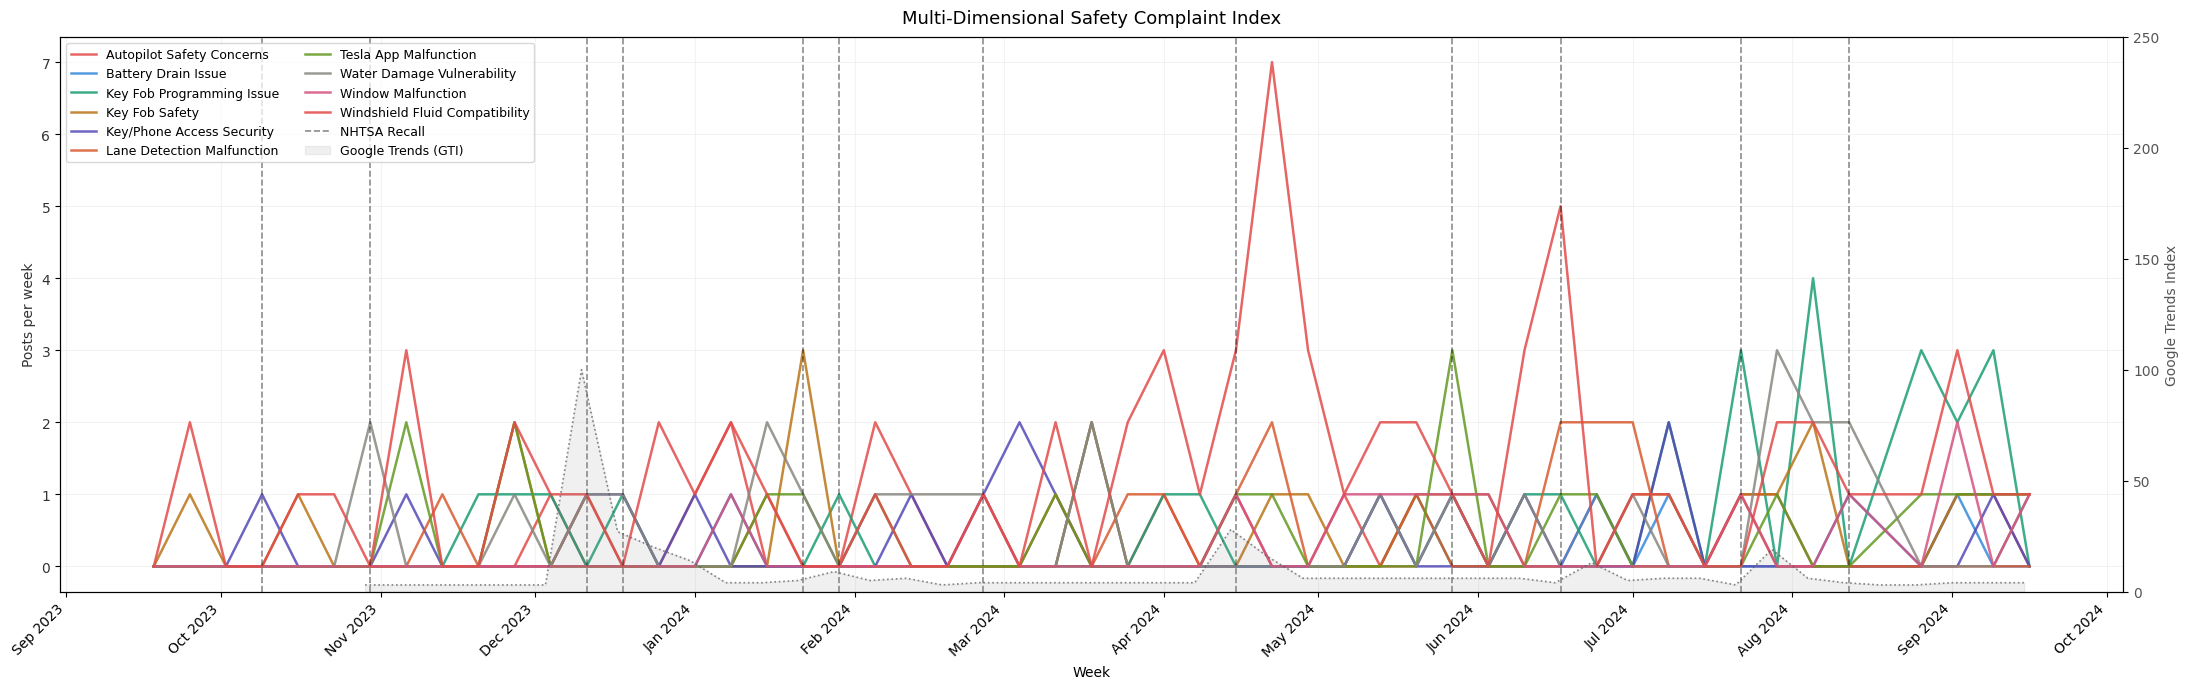

In [ ]:
# multi dim SCI plot
COLORS = [
    '#E24B4A', '#378ADD', '#1D9E75', '#BA7517',
    '#534AB7', '#D85A30', '#639922', '#888780', '#D4537E'
]

plot_cols = [c for c in topic_weekly.columns if c.lower() != 'other']

fig, ax1 = plt.subplots(figsize=(22, 7))

for i, col in enumerate(plot_cols):
    ax1.plot(
        topic_weekly.index,
        topic_weekly[col],
        label=col.replace('_', ' ').title(),
        linewidth=1.8,
        color=COLORS[i % len(COLORS)],
        alpha=0.85
    )

first_label = True
for rw in weekly_recalls['week_start']:
    ax1.axvline(
        x=pd.to_datetime(rw), color='black', linestyle='--',
        linewidth=1.2, alpha=0.45,
        label='NHTSA Recall' if first_label else None
    )
    first_label = False

ax1.set_xlabel('Week')
ax1.set_ylabel('Posts per week', color='#333333')
ax1.tick_params(axis='y', labelcolor='#333333')
ax1.grid(True, alpha=0.15)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right')

gti_plot = trends_aligned[trends_aligned['GTI'] > 0].copy()
gti_plot['week_start'] = pd.to_datetime(gti_plot['week_start'])

if len(gti_plot) > 0:
    ax2 = ax1.twinx()
    ax2.fill_between(gti_plot['week_start'], gti_plot['GTI'],
                     alpha=0.12, color='#888888', label='Google Trends (GTI)')
    ax2.plot(gti_plot['week_start'], gti_plot['GTI'],
             color='#555555', linewidth=1.2, linestyle=':', alpha=0.7)
    ax2.set_ylabel('Google Trends Index', color='#555555')
    ax2.tick_params(axis='y', labelcolor='#555555')
    ax2.set_ylim(0, gti_plot['GTI'].max() * 2.5)
    lines2, labels2 = ax2.get_legend_handles_labels()
else:
    lines2, labels2 = [], []

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=9, framealpha=0.75, ncol=2)
ax1.set_title('Multi-Dimensional Safety Complaint Index', fontsize=13, pad=10)

plt.tight_layout()
plt.show()
